# 16 - Feature Space Visualization from Saved CSV

Notebook ini hanya membuat grafik dari artifact CSV yang sudah tersimpan. Tidak ada proses training ulang XGBoost/MLP.

Visualisasi yang dibuat:
- t-SNE 2 dimensi untuk fitur CLIP only.
- t-SNE 2 dimensi untuk fitur FFT + CLIP.
- t-SNE 2 dimensi untuk seluruh fitur gabungan (`CLIP + FFT + IQA`).
- Scatter fitur FFT, terutama `fft_mag_mean` dan fitur fase.
- Scatter fitur NR-IQA, terutama PIQE, BRISQUE, dan NIQE.
- Grafik performa model dari CSV hasil eksperimen.

Catatan: t-SNE di sini hanya dipakai sebagai reduksi dimensi untuk visualisasi, bukan sebagai training classifier. Sumbu t-SNE tidak memiliki satuan fisik; yang dibaca adalah kedekatan/pengelompokan titik secara relatif.


In [1]:
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

sns.set_theme(style="whitegrid")

PROJECT_ROOT = Path("..").resolve()
ARTIFACT_DIR = PROJECT_ROOT / "artifacts"
FIGURE_DIR = ARTIFACT_DIR / "figures"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

CSV_ALL = ARTIFACT_DIR / "feature_vector_biggan_midjourney_cat4_iqa_fft_clip.csv"
CSV_CLIP = ARTIFACT_DIR / "feature_vector_biggan_midjourney_cat4_clip_only.csv"
CSV_FFT_CLIP = ARTIFACT_DIR / "feature_vector_biggan_midjourney_cat4_fft_clip.csv"
CSV_IQA = ARTIFACT_DIR / "feature_vector_biggan_midjourney_cat4_iqa_only.csv"

RESULT_FILES = {
    "FFT only": ARTIFACT_DIR / "results_classification_biggan_midjourney_cat4_fft_only.csv",
    "CLIP only": ARTIFACT_DIR / "results_classification_biggan_midjourney_cat4_clip_only.csv",
    "IQA only": ARTIFACT_DIR / "results_classification_biggan_midjourney_cat4_iqa_only.csv",
    "FFT + CLIP": ARTIFACT_DIR / "results_classification_biggan_midjourney_cat4_fft_clip.csv",
    "IQA + FFT": ARTIFACT_DIR / "results_classification_biggan_midjourney_cat4_iqa_fft.csv",
    "IQA + CLIP": ARTIFACT_DIR / "results_classification_biggan_midjourney_cat4_iqa_clip.csv",
    "IQA + FFT + CLIP": ARTIFACT_DIR / "results_classification_biggan_midjourney_cat4_iqa_fft_clip.csv",
}

print("Project root:", PROJECT_ROOT)
print("Artifact dir:", ARTIFACT_DIR)
print("Figure dir:", FIGURE_DIR)


Project root: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold
Artifact dir: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts
Figure dir: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures


In [2]:
# Load feature vectors yang sudah ada. Tidak ada ekstraksi ulang dan tidak ada training ulang.
all_df = pd.read_csv(CSV_ALL)
clip_df = pd.read_csv(CSV_CLIP)
fft_clip_df = pd.read_csv(CSV_FFT_CLIP)
iqa_df = pd.read_csv(CSV_IQA)

label_map = {0: "Nature", 1: "AI"}
for df in [all_df, clip_df, fft_clip_df, iqa_df]:
    df["label"] = df["y_ai"].map(label_map)

print("All feature vector:", all_df.shape)
print("CLIP vector:", clip_df.shape)
print("FFT + CLIP vector:", fft_clip_df.shape)
print("IQA vector:", iqa_df.shape)
print("Label distribution:")
display(all_df["label"].value_counts())
print("Generator x label:")
display(all_df.groupby(["generator", "label"]).size().unstack(fill_value=0))
print("Class x label:")
display(all_df.groupby(["class_name", "label"]).size().unstack(fill_value=0))

All feature vector: (1600, 83)
CLIP vector: (1600, 76)
FFT + CLIP vector: (1600, 80)
IQA vector: (1600, 15)
Label distribution:


label
AI        800
Nature    800
Name: count, dtype: int64

Generator x label:


label,AI,Nature
generator,,
BigGAN,400,400
MidJourney,400,400


Class x label:


label,AI,Nature
class_name,,
ai,800,0
nature,0,800


In [3]:
def savefig(name: str):
    path = FIGURE_DIR / name
    plt.tight_layout()
    plt.savefig(path, dpi=200, bbox_inches="tight")
    print("Saved:", path.resolve())

PALETTE = {"Nature": "#2ca25f", "AI": "#de2d26"}

def layered_label_scatter(ax, data, xcol, ycol, title, style_col="generator"):
    """Gambar Nature lebih dulu, lalu AI di atasnya agar titik AI tidak tertutup."""
    marker_map = {"BigGAN": "o", "MidJourney": "X"}
    plot_specs = [
        ("Nature", "#2ca25f", 28, 0.28, 1),
        ("AI", "#de2d26", 36, 0.82, 2),
    ]

    for label, color, size, alpha, zorder in plot_specs:
        label_df = data[data["label"] == label]
        for generator, marker in marker_map.items():
            subset = label_df[label_df[style_col] == generator]
            if subset.empty:
                continue
            ax.scatter(
                subset[xcol],
                subset[ycol],
                s=size,
                c=color,
                marker=marker,
                alpha=alpha,
                edgecolors="black" if label == "AI" else "none",
                linewidths=0.25 if label == "AI" else 0,
                label=f"{label} - {generator}",
                zorder=zorder,
                rasterized=True,
            )

    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(True, alpha=0.25)


def plot_tsne_ai_on_top(data, xcol, ycol, title, filename):
    fig, ax = plt.subplots(figsize=(9, 7))
    layered_label_scatter(ax, data, xcol, ycol, title)
    handles, labels = ax.get_legend_handles_labels()
    ax.legend(handles, labels, loc="best", frameon=True)
    savefig(filename)
    plt.show()


def plot_tsne_by_label(data, xcol, ycol, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharex=True, sharey=True)
    for ax, label in zip(axes, ["Nature", "AI"]):
        subset = data[data["label"] == label]
        sns.scatterplot(
            data=subset,
            x=xcol,
            y=ycol,
            hue="generator",
            style="generator",
            alpha=0.65,
            s=32,
            ax=ax,
        )
        ax.set_title(f"{title} - {label}")
        ax.grid(True, alpha=0.25)
    plt.suptitle(f"{title} separated by label", y=1.02)
    savefig(filename)
    plt.show()

def layered_label_scatter_with_order(ax, data, xcol, ycol, title, top_label="AI", style_col="generator"):
    """Plot dua label dengan pilihan label yang digambar paling atas."""
    marker_map = {"BigGAN": "o", "MidJourney": "X"}
    label_styles = {
        "Nature": {"color": "#2ca25f"},
        "AI": {"color": "#de2d26"},
    }
    order = ["Nature", "AI"]
    if top_label == "Nature":
        order = ["AI", "Nature"]

    for zorder, label in enumerate(order, start=1):
        label_df = data[data["label"] == label]
        is_top = label == top_label
        for generator, marker in marker_map.items():
            subset = label_df[label_df[style_col] == generator]
            if subset.empty:
                continue
            ax.scatter(
                subset[xcol],
                subset[ycol],
                s=36 if is_top else 28,
                c=label_styles[label]["color"],
                marker=marker,
                alpha=0.82 if is_top else 0.28,
                edgecolors="black" if is_top else "none",
                linewidths=0.25 if is_top else 0,
                label=f"{label} - {generator}",
                zorder=zorder,
                rasterized=True,
            )

    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(True, alpha=0.25)


## t-SNE Fitur CLIP

Grafik ini mereduksi embedding CLIP menjadi dua dimensi menggunakan t-SNE agar pola lokal antar sampel bisa divisualisasikan. Jika titik AI dan Nature membentuk kecenderungan kelompok berbeda, berarti embedding CLIP menyimpan sinyal visual/semantik yang dapat dipakai untuk klasifikasi.

Berbeda dari PCA, sumbu t-SNE tidak mewakili persentase variansi dan tidak memiliki satuan fisik. Interpretasinya berfokus pada kedekatan relatif antar titik dan pola pengelompokan.


CLIP feature columns: 64
t-SNE perplexity: 30


,image_id,generator,class_name,label,y_ai,clip_tsne_1,clip_tsne_2
0,img_c429cc2dec1ec373,BigGAN,ai,AI,1,18.542788,-30.981585
1,img_4b9285a38c5f9404,BigGAN,ai,AI,1,18.132832,-23.006826
2,img_6b66a33f59efecea,BigGAN,ai,AI,1,32.241676,-27.256153
3,img_516f97fb24215ba9,BigGAN,ai,AI,1,11.326407,-26.389393
4,img_b0dae84b71c78468,BigGAN,ai,AI,1,10.249273,-30.057434


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_clip_tsne_ai_vs_nature.png


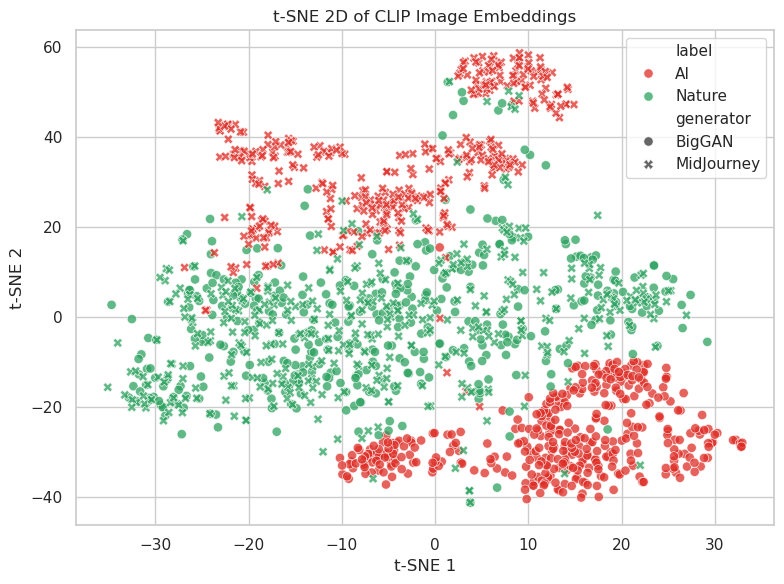

In [4]:
def compute_tsne_2d(features, random_state=42, perplexity=30):
    """Standarisasi fitur lalu proyeksikan ke t-SNE 2D untuk visualisasi."""
    n_samples = features.shape[0]
    safe_perplexity = min(perplexity, max(5, (n_samples - 1) // 3))
    scaled = StandardScaler().fit_transform(features)
    tsne = TSNE(
        n_components=2,
        perplexity=safe_perplexity,
        learning_rate="auto",
        init="random",
        random_state=random_state,
    )
    return tsne.fit_transform(scaled), safe_perplexity

clip_cols = [c for c in clip_df.columns if c.startswith("clip_feat_")]
X_clip = clip_df[clip_cols].to_numpy(dtype=np.float32)
clip_xy, clip_perplexity = compute_tsne_2d(X_clip)

clip_vis = clip_df[["image_id", "generator", "class_name", "label", "y_ai"]].copy()
clip_vis["clip_tsne_1"] = clip_xy[:, 0]
clip_vis["clip_tsne_2"] = clip_xy[:, 1]

print("CLIP feature columns:", len(clip_cols))
print("t-SNE perplexity:", clip_perplexity)
display(clip_vis.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=clip_vis,
    x="clip_tsne_1",
    y="clip_tsne_2",
    hue="label",
    style="generator",
    palette=PALETTE,
    alpha=0.75,
    s=45,
)
plt.title("t-SNE 2D of CLIP Image Embeddings")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
savefig("16_clip_tsne_ai_vs_nature.png")
plt.show()


plot_tsne_ai_on_top(
    clip_vis,
    "clip_tsne_1",
    "clip_tsne_2",
    "CLIP t-SNE (AI points drawn on top)",
    "16_clip_tsne_ai_on_top.png",
)

plot_tsne_by_label(
    clip_vis,
    "clip_tsne_1",
    "clip_tsne_2",
    "CLIP t-SNE",
    "16_clip_tsne_by_label.png",
)


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_clip_tsne_by_generator.png


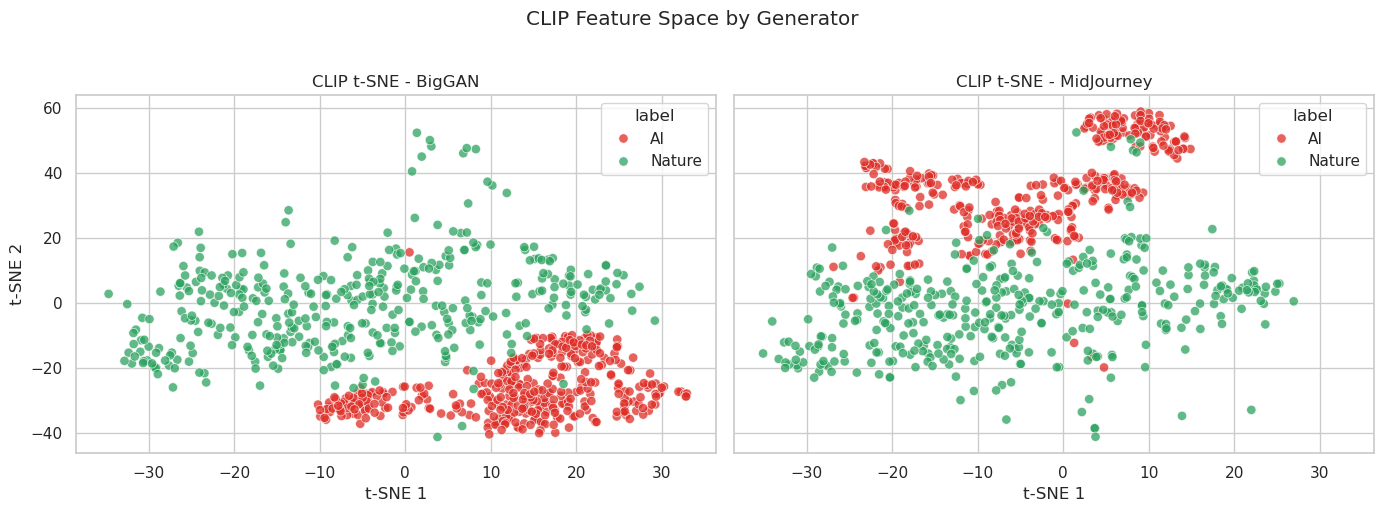

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, generator in zip(axes, sorted(clip_vis["generator"].unique())):
    subset = clip_vis[clip_vis["generator"] == generator]
    sns.scatterplot(
        data=subset,
        x="clip_tsne_1",
        y="clip_tsne_2",
        hue="label",
        palette=PALETTE,
        alpha=0.75,
        s=45,
        ax=ax,
    )
    ax.set_title(f"CLIP t-SNE - {generator}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
plt.suptitle("CLIP Feature Space by Generator", y=1.02)
savefig("16_clip_tsne_by_generator.png")
plt.show()


## t-SNE Fitur FFT + CLIP

Bagian ini memakai fitur gabungan FFT dan CLIP dari CSV `feature_vector_biggan_midjourney_cat4_fft_clip.csv`. Visualisasi ini digunakan untuk melihat ruang fitur dari konfigurasi yang memperoleh performa terbaik pada eksperimen klasifikasi.

Seperti visualisasi t-SNE lainnya, grafik ini hanya digunakan untuk interpretasi pola kedekatan relatif antar sampel dan tidak digunakan sebagai fitur pelatihan model.


FFT + CLIP feature columns: 68
- FFT columns: 4
- CLIP columns: 64
t-SNE perplexity: 30


,image_id,generator,class_name,label,y_ai,fft_clip_tsne_1,fft_clip_tsne_2
0,img_c429cc2dec1ec373,BigGAN,ai,AI,1,-8.483376,-46.586830
1,img_4b9285a38c5f9404,BigGAN,ai,AI,1,-11.367957,-52.613205
2,img_6b66a33f59efecea,BigGAN,ai,AI,1,14.447961,-51.770229
3,img_516f97fb24215ba9,BigGAN,ai,AI,1,3.524101,-48.123291
4,img_b0dae84b71c78468,BigGAN,ai,AI,1,-3.224331,-44.356670


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_fft_clip_tsne_ai_vs_nature.png


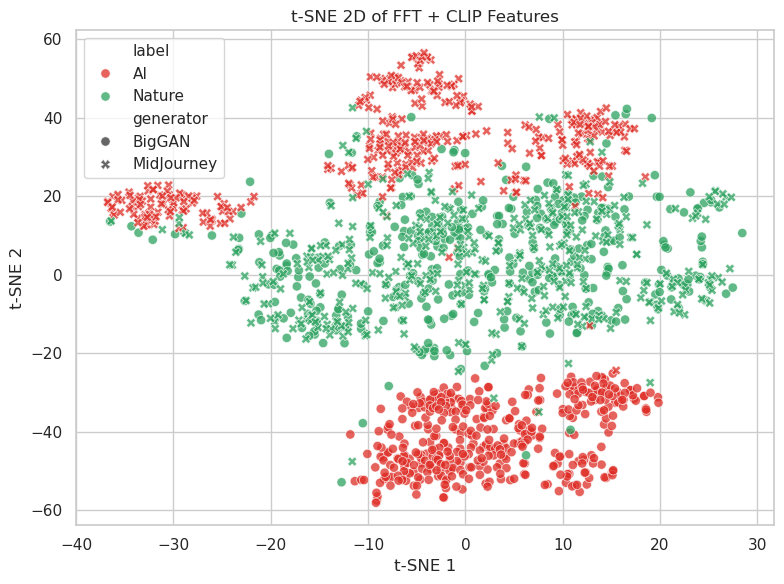

In [6]:
fft_cols = ["fft_mag_mean", "fft_phase_mean", "fft_phase_cos_mean", "fft_phase_sin_mean"]
clip_cols_fft_clip = [c for c in fft_clip_df.columns if c.startswith("clip_feat_")]
fft_clip_feature_cols = fft_cols + clip_cols_fft_clip

X_fft_clip = fft_clip_df[fft_clip_feature_cols].to_numpy(dtype=np.float32)
fft_clip_xy, fft_clip_perplexity = compute_tsne_2d(X_fft_clip)

fft_clip_vis = fft_clip_df[["image_id", "generator", "class_name", "label", "y_ai"]].copy()
fft_clip_vis["fft_clip_tsne_1"] = fft_clip_xy[:, 0]
fft_clip_vis["fft_clip_tsne_2"] = fft_clip_xy[:, 1]

print("FFT + CLIP feature columns:", len(fft_clip_feature_cols))
print("- FFT columns:", len(fft_cols))
print("- CLIP columns:", len(clip_cols_fft_clip))
print("t-SNE perplexity:", fft_clip_perplexity)
display(fft_clip_vis.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=fft_clip_vis,
    x="fft_clip_tsne_1",
    y="fft_clip_tsne_2",
    hue="label",
    style="generator",
    palette=PALETTE,
    alpha=0.75,
    s=45,
)
plt.title("t-SNE 2D of FFT + CLIP Features")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
savefig("16_fft_clip_tsne_ai_vs_nature.png")
plt.show()


plot_tsne_ai_on_top(
    fft_clip_vis,
    "fft_clip_tsne_1",
    "fft_clip_tsne_2",
    "FFT + CLIP t-SNE (AI points drawn on top)",
    "16_fft_clip_tsne_ai_on_top.png",
)

plot_tsne_by_label(
    fft_clip_vis,
    "fft_clip_tsne_1",
    "fft_clip_tsne_2",
    "FFT + CLIP t-SNE",
    "16_fft_clip_tsne_by_label.png",
)


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_fft_clip_tsne_by_generator.png


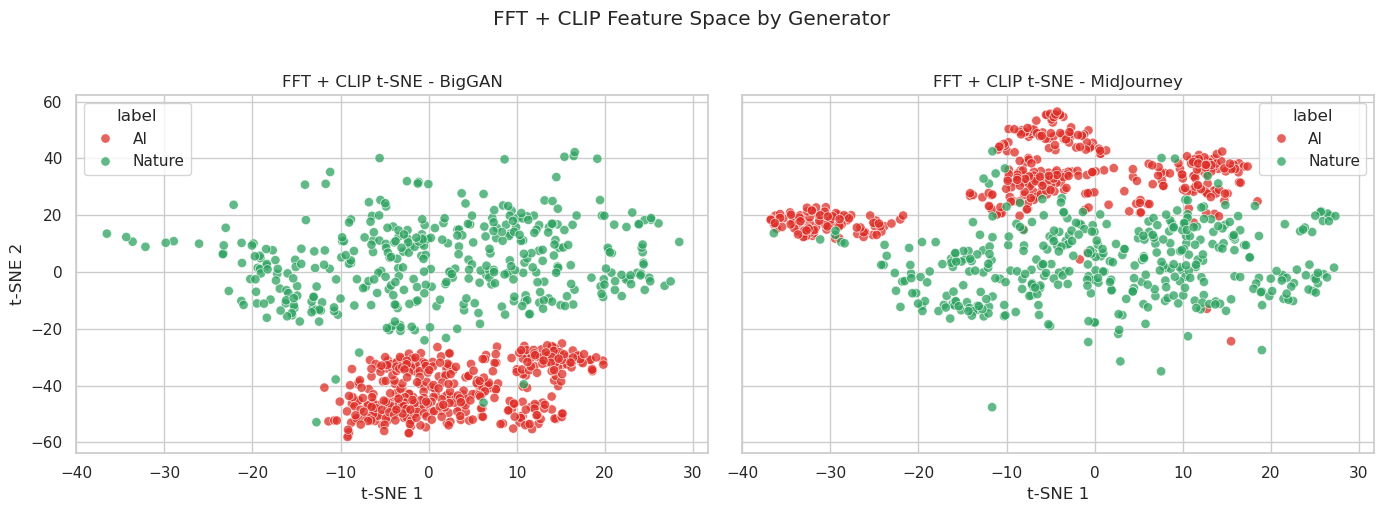

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, generator in zip(axes, sorted(fft_clip_vis["generator"].unique())):
    subset = fft_clip_vis[fft_clip_vis["generator"] == generator]
    sns.scatterplot(
        data=subset,
        x="fft_clip_tsne_1",
        y="fft_clip_tsne_2",
        hue="label",
        palette=PALETTE,
        alpha=0.75,
        s=45,
        ax=ax,
    )
    ax.set_title(f"FFT + CLIP t-SNE - {generator}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
plt.suptitle("FFT + CLIP Feature Space by Generator", y=1.02)
savefig("16_fft_clip_tsne_by_generator.png")
plt.show()


## t-SNE Semua Fitur Gabungan

Bagian ini memakai seluruh fitur gabungan dari CSV `feature_vector_biggan_midjourney_cat4_iqa_fft_clip.csv`, yaitu fitur FFT, CLIP, dan NR-IQA. Tujuannya adalah melihat apakah kombinasi semua dimensi fitur membentuk ruang 2D yang lebih terpisah antara AI dan Nature dibandingkan CLIP only.

Sama seperti t-SNE CLIP, grafik ini hanya visualisasi dari artifact CSV yang sudah tersimpan dan tidak melakukan training ulang.


All feature columns: 71
- FFT columns: 4
- CLIP columns: 64
- IQA columns: 3
t-SNE perplexity: 30


,image_id,generator,class_name,label,y_ai,all_tsne_1,all_tsne_2
0,img_c429cc2dec1ec373,BigGAN,ai,AI,1,-11.840412,-44.130596
1,img_4b9285a38c5f9404,BigGAN,ai,AI,1,-18.607193,-44.943779
2,img_6b66a33f59efecea,BigGAN,ai,AI,1,-24.612934,-51.200634
3,img_516f97fb24215ba9,BigGAN,ai,AI,1,-5.638612,-51.611149
4,img_b0dae84b71c78468,BigGAN,ai,AI,1,-7.826507,-44.246445


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_all_features_tsne_ai_vs_nature.png


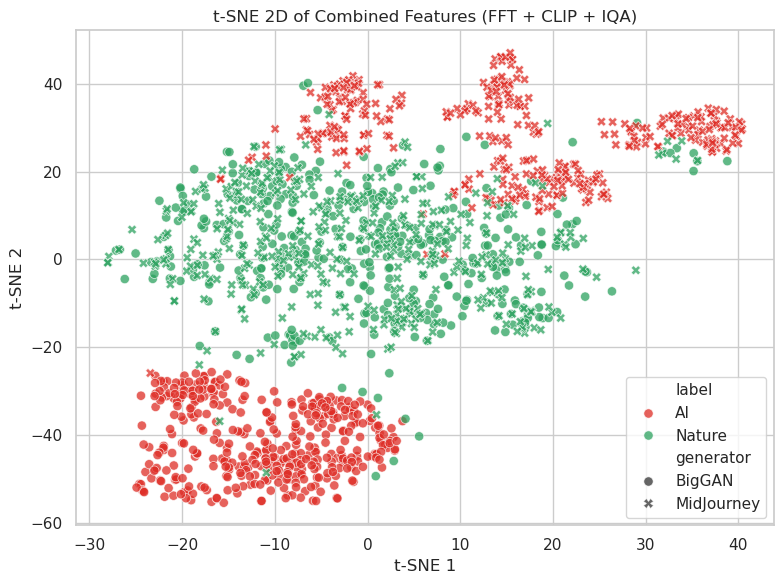

In [8]:
fft_cols_all = ["fft_mag_mean", "fft_phase_mean", "fft_phase_cos_mean", "fft_phase_sin_mean"]
iqa_cols_all = ["piqe", "brisque", "niqe"]
clip_cols_all = [c for c in all_df.columns if c.startswith("clip_feat_")]
all_feature_cols = fft_cols_all + clip_cols_all + iqa_cols_all

X_all = all_df[all_feature_cols].to_numpy(dtype=np.float32)
all_xy, all_perplexity = compute_tsne_2d(X_all)

all_tsne_vis = all_df[["image_id", "generator", "class_name", "label", "y_ai"]].copy()
all_tsne_vis["all_tsne_1"] = all_xy[:, 0]
all_tsne_vis["all_tsne_2"] = all_xy[:, 1]

print("All feature columns:", len(all_feature_cols))
print("- FFT columns:", len(fft_cols_all))
print("- CLIP columns:", len(clip_cols_all))
print("- IQA columns:", len(iqa_cols_all))
print("t-SNE perplexity:", all_perplexity)
display(all_tsne_vis.head())

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=all_tsne_vis,
    x="all_tsne_1",
    y="all_tsne_2",
    hue="label",
    style="generator",
    palette=PALETTE,
    alpha=0.75,
    s=45,
)
plt.title("t-SNE 2D of Combined Features (FFT + CLIP + IQA)")
plt.xlabel("t-SNE 1")
plt.ylabel("t-SNE 2")
savefig("16_all_features_tsne_ai_vs_nature.png")
plt.show()


plot_tsne_ai_on_top(
    all_tsne_vis,
    "all_tsne_1",
    "all_tsne_2",
    "Combined Features t-SNE (AI points drawn on top)",
    "16_all_features_tsne_ai_on_top.png",
)

plot_tsne_by_label(
    all_tsne_vis,
    "all_tsne_1",
    "all_tsne_2",
    "Combined Features t-SNE",
    "16_all_features_tsne_by_label.png",
)


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_all_features_tsne_by_generator.png


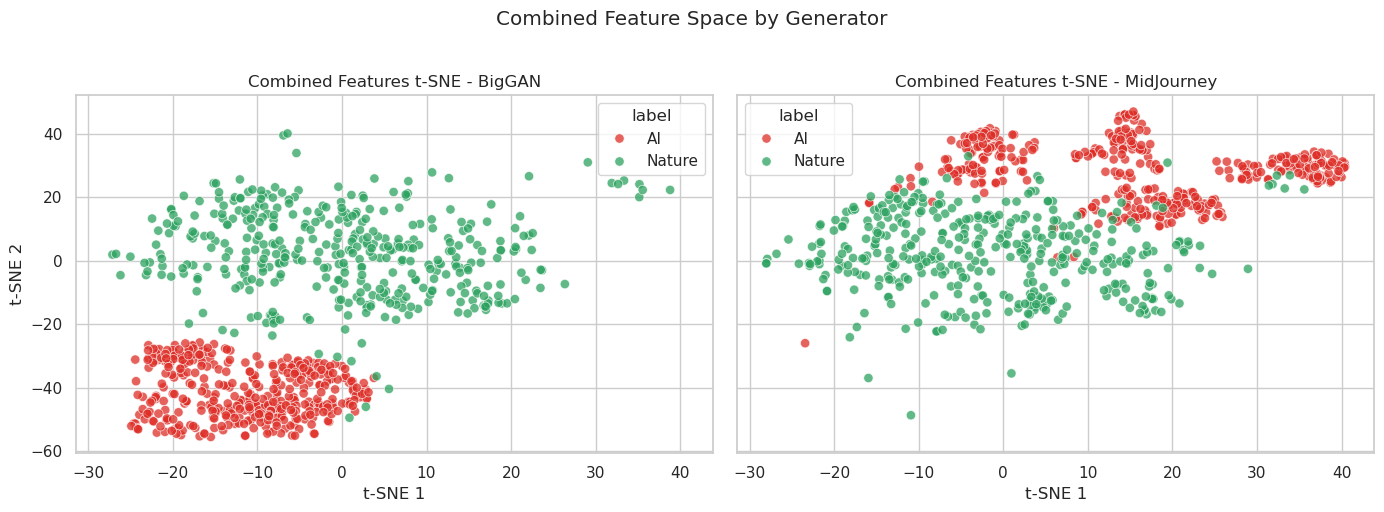

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharex=True, sharey=True)
for ax, generator in zip(axes, sorted(all_tsne_vis["generator"].unique())):
    subset = all_tsne_vis[all_tsne_vis["generator"] == generator]
    sns.scatterplot(
        data=subset,
        x="all_tsne_1",
        y="all_tsne_2",
        hue="label",
        palette=PALETTE,
        alpha=0.75,
        s=45,
        ax=ax,
    )
    ax.set_title(f"Combined Features t-SNE - {generator}")
    ax.set_xlabel("t-SNE 1")
    ax.set_ylabel("t-SNE 2")
plt.suptitle("Combined Feature Space by Generator", y=1.02)
savefig("16_all_features_tsne_by_generator.png")
plt.show()


## Scatter Fitur FFT

Grafik ini memakai fitur FFT yang sudah tersimpan. Fokusnya adalah melihat apakah fitur magnitudo dan fase menunjukkan pola distribusi berbeda antara AI dan Nature.

,fft_mag_mean,fft_phase_mean,fft_phase_cos_mean,fft_phase_sin_mean
count,1600.000000,1600.000000,1600.000000,1.600000e+03
mean,5025.688487,0.000077,0.002407,1.046980e-11
std,2831.834597,0.000149,0.019439,8.738773e-10
min,894.797119,-0.000641,-0.139593,-7.450581e-09
25%,2290.328308,0.000000,-0.003354,-1.309672e-10
50%,4906.262451,0.000006,0.000318,0.000000e+00
75%,6743.854736,0.000069,0.006741,1.164153e-10
max,19853.949219,0.000575,0.172363,7.450581e-09


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_fft_scatter_ai_vs_nature.png


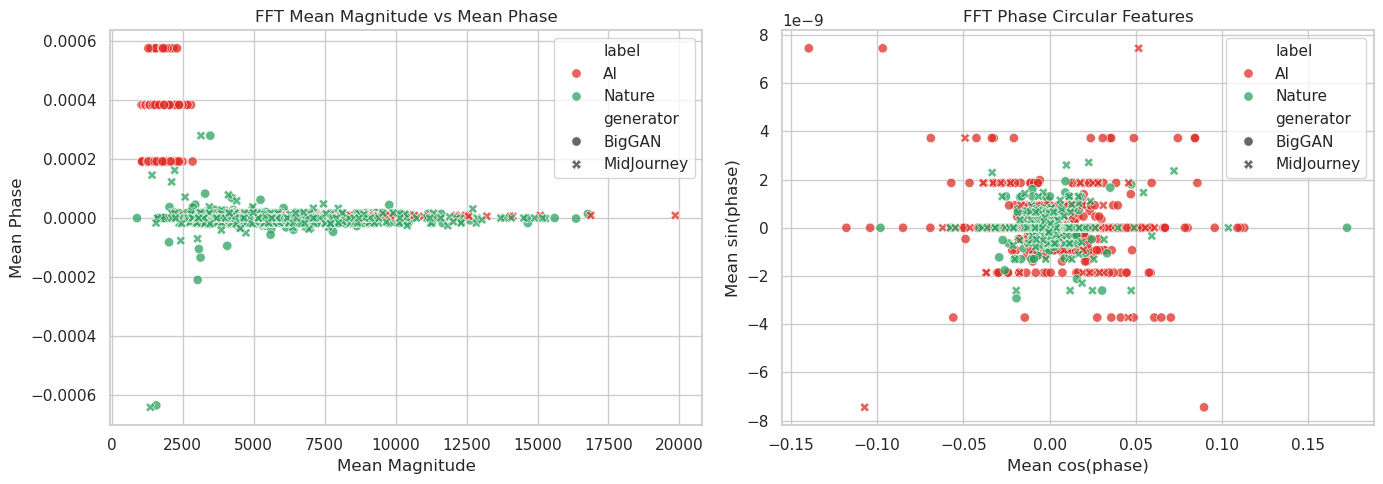

In [10]:
fft_cols = ["fft_mag_mean", "fft_phase_mean", "fft_phase_cos_mean", "fft_phase_sin_mean"]
fft_df = all_df[["image_id", "generator", "class_name", "label", "y_ai", *fft_cols]].copy()

display(fft_df[fft_cols].describe())


def layered_fft_scatter(ax, xcol, ycol, title):
    """Gambar Nature lebih dulu, lalu AI di atasnya agar titik AI tidak tertutup."""
    marker_map = {"BigGAN": "o", "MidJourney": "X"}
    plot_specs = [
        ("Nature", "#2ca25f", 28, 0.28, 1),
        ("AI", "#de2d26", 36, 0.82, 2),
    ]

    for label, color, size, alpha, zorder in plot_specs:
        label_df = fft_df[fft_df["label"] == label]
        for generator, marker in marker_map.items():
            subset = label_df[label_df["generator"] == generator]
            if subset.empty:
                continue
            ax.scatter(
                subset[xcol],
                subset[ycol],
                s=size,
                c=color,
                marker=marker,
                alpha=alpha,
                edgecolors="black" if label == "AI" else "none",
                linewidths=0.25 if label == "AI" else 0,
                label=f"{label} - {generator}",
                zorder=zorder,
                rasterized=True,
            )

    ax.set_title(title)
    ax.set_xlabel(xcol)
    ax.set_ylabel(ycol)
    ax.grid(True, alpha=0.25)


fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
layered_fft_scatter(
    axes[0],
    "fft_mag_mean",
    "fft_phase_mean",
    "FFT Mean Magnitude vs Mean Phase",
)
layered_fft_scatter(
    axes[1],
    "fft_phase_cos_mean",
    "fft_phase_sin_mean",
    "FFT Phase Circular Features",
)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=True)
plt.suptitle("FFT Scatter Plot with AI Points Drawn on Top", y=1.03)
plt.subplots_adjust(bottom=0.22)
savefig("16_fft_scatter_ai_on_top.png")
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(14, 10), sharex="col", sharey="col")
pairs = [
    ("fft_mag_mean", "fft_phase_mean", "Mean Magnitude vs Mean Phase"),
    ("fft_phase_cos_mean", "fft_phase_sin_mean", "Mean cos(phase) vs Mean sin(phase)"),
]
labels_order = ["Nature", "AI"]

for row_idx, label in enumerate(labels_order):
    subset = fft_df[fft_df["label"] == label]
    for col_idx, (xcol, ycol, title) in enumerate(pairs):
        ax = axes[row_idx, col_idx]
        sns.scatterplot(
            data=subset,
            x=xcol,
            y=ycol,
            hue="generator",
            style="generator",
            alpha=0.65,
            s=30,
            ax=ax,
        )
        ax.set_title(f"{label}: {title}")
        ax.grid(True, alpha=0.25)

plt.suptitle("FFT Scatter Plot Separated by Label", y=1.02)
savefig("16_fft_scatter_by_label.png")
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))
layered_label_scatter_with_order(
    axes[0],
    fft_df,
    "fft_mag_mean",
    "fft_phase_mean",
    "FFT Mean Magnitude vs Mean Phase",
    top_label="Nature",
)
layered_label_scatter_with_order(
    axes[1],
    fft_df,
    "fft_phase_cos_mean",
    "fft_phase_sin_mean",
    "FFT Phase Circular Features",
    top_label="Nature",
)
handles, labels = axes[1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=True)
plt.suptitle("FFT Scatter Plot with Nature Points Drawn on Top", y=1.03)
plt.subplots_adjust(bottom=0.22)
savefig("16_fft_scatter_nature_on_top.png")
plt.show()


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_fft_feature_distributions.png


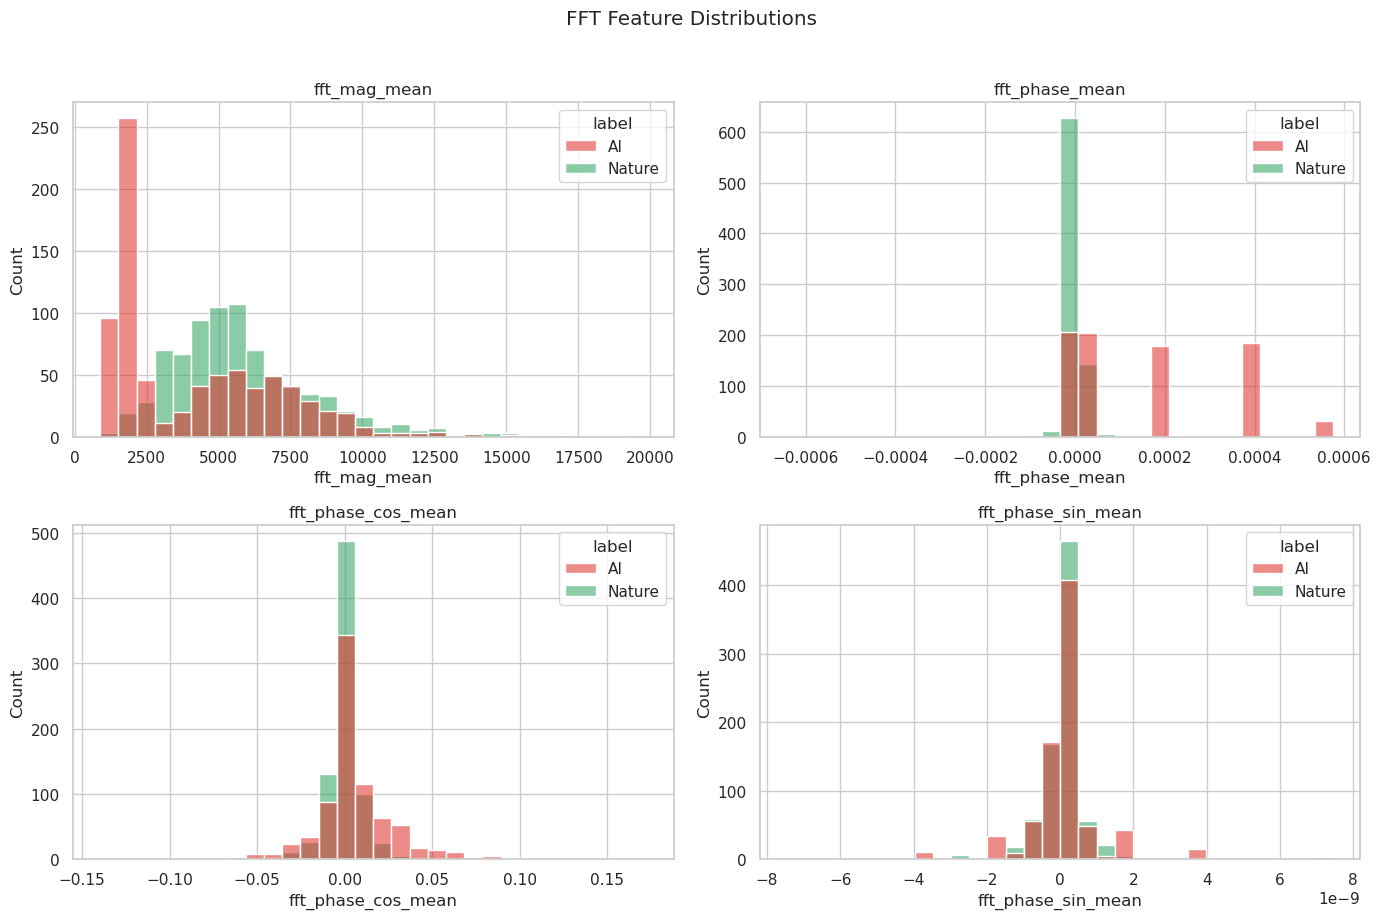

In [11]:
# Distribusi tiap fitur FFT agar pemisahan marginal terlihat tanpa saling menutupi.
fft_long = fft_df.melt(
    id_vars=["image_id", "generator", "class_name", "label", "y_ai"],
    value_vars=fft_cols,
    var_name="feature",
    value_name="value",
)

fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, col in zip(axes, fft_cols):
    sns.ecdfplot(
        data=fft_df,
        x=col,
        hue="label",
        palette=PALETTE,
        linewidth=2,
        ax=ax,
    )
    ax.set_title(f"ECDF {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Cumulative proportion")
    ax.grid(True, alpha=0.25)

plt.suptitle("FFT Feature ECDF by Label", y=1.02)
savefig("16_fft_feature_ecdf_by_label.png")
plt.show()


fig, axes = plt.subplots(2, 2, figsize=(14, 9))
axes = axes.ravel()

for ax, col in zip(axes, fft_cols):
    sns.histplot(
        data=fft_df,
        x=col,
        hue="label",
        palette=PALETTE,
        bins=40,
        element="step",
        fill=False,
        stat="density",
        common_norm=False,
        linewidth=1.8,
        ax=ax,
    )
    ax.set_title(f"Density Histogram {col}")
    ax.set_xlabel(col)
    ax.set_ylabel("Density")
    ax.grid(True, alpha=0.25)

plt.suptitle("FFT Feature Density Histogram by Label", y=1.02)
savefig("16_fft_feature_density_by_label.png")
plt.show()


plt.figure(figsize=(12, 6))
sns.boxplot(
    data=fft_long,
    x="feature",
    y="value",
    hue="label",
    palette=PALETTE,
    showfliers=False,
)
plt.title("FFT Feature Value Distribution by Label")
plt.xlabel("FFT feature")
plt.ylabel("Feature value")
plt.xticks(rotation=15)
savefig("16_fft_feature_boxplot_by_label.png")
plt.show()


## Scatter Fitur NR-IQA

Grafik ini menampilkan hubungan skor PIQE, BRISQUE, dan NIQE. Jika distribusi AI dan Nature saling tumpang tindih, artinya fitur IQA saja mungkin tidak cukup kuat. Jika ada pemisahan, maka metrik kualitas citra memiliki sinyal pembeda.

,piqe,brisque,niqe
count,1600.000000,1600.000000,1600.000000
mean,38.025318,25.970134,5.021063
std,17.130290,20.438983,1.388325
min,5.644852,-21.958069,2.002004
25%,24.242537,9.142624,3.975343
50%,34.990164,26.807068,5.030354
75%,52.285192,41.128403,5.794257
max,89.732521,128.322998,13.564471


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_iqa_scatter_ai_vs_nature.png


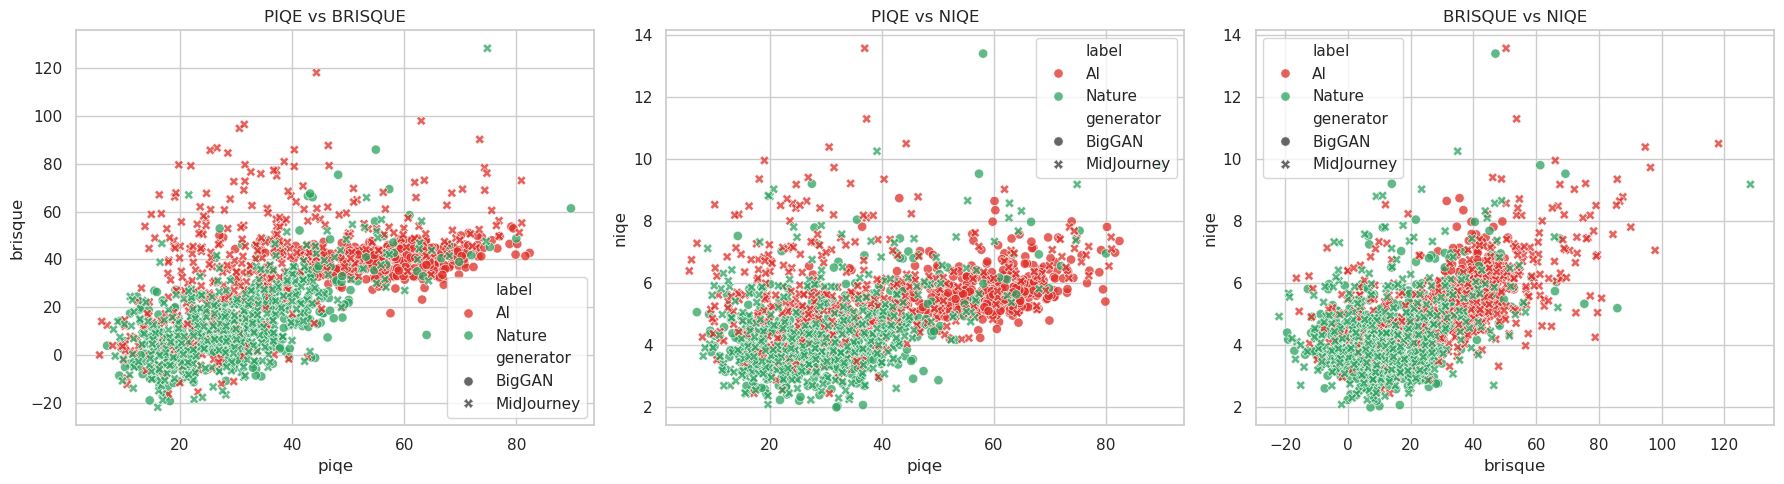

In [12]:
iqa_cols = ["piqe", "brisque", "niqe"]
iqa_vis = iqa_df[["image_id", "generator", "class_name", "label", "y_ai", *iqa_cols]].copy()

display(iqa_vis[iqa_cols].describe())

pairs = [("piqe", "brisque"), ("piqe", "niqe"), ("brisque", "niqe")]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (xcol, ycol) in zip(axes, pairs):
    layered_label_scatter_with_order(
        ax,
        iqa_vis,
        xcol,
        ycol,
        f"{xcol.upper()} vs {ycol.upper()}",
        top_label="AI",
    )
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=True)
plt.suptitle("NR-IQA Scatter Plot with AI Points Drawn on Top", y=1.04)
plt.subplots_adjust(bottom=0.23)
savefig("16_iqa_scatter_ai_on_top.png")
plt.show()


fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, (xcol, ycol) in zip(axes, pairs):
    layered_label_scatter_with_order(
        ax,
        iqa_vis,
        xcol,
        ycol,
        f"{xcol.upper()} vs {ycol.upper()}",
        top_label="Nature",
    )
handles, labels = axes[-1].get_legend_handles_labels()
fig.legend(handles, labels, loc="lower center", ncol=4, frameon=True)
plt.suptitle("NR-IQA Scatter Plot with Nature Points Drawn on Top", y=1.04)
plt.subplots_adjust(bottom=0.23)
savefig("16_iqa_scatter_nature_on_top.png")
plt.show()


fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharex="col", sharey="col")
for row_idx, label in enumerate(["Nature", "AI"]):
    subset = iqa_vis[iqa_vis["label"] == label]
    for col_idx, (xcol, ycol) in enumerate(pairs):
        ax = axes[row_idx, col_idx]
        sns.scatterplot(
            data=subset,
            x=xcol,
            y=ycol,
            hue="generator",
            style="generator",
            alpha=0.65,
            s=32,
            ax=ax,
        )
        ax.set_title(f"{label}: {xcol.upper()} vs {ycol.upper()}")
        ax.grid(True, alpha=0.25)

plt.suptitle("NR-IQA Scatter Plot Separated by Label", y=1.02)
savefig("16_iqa_scatter_by_label.png")
plt.show()


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_iqa_boxplot_by_label.png


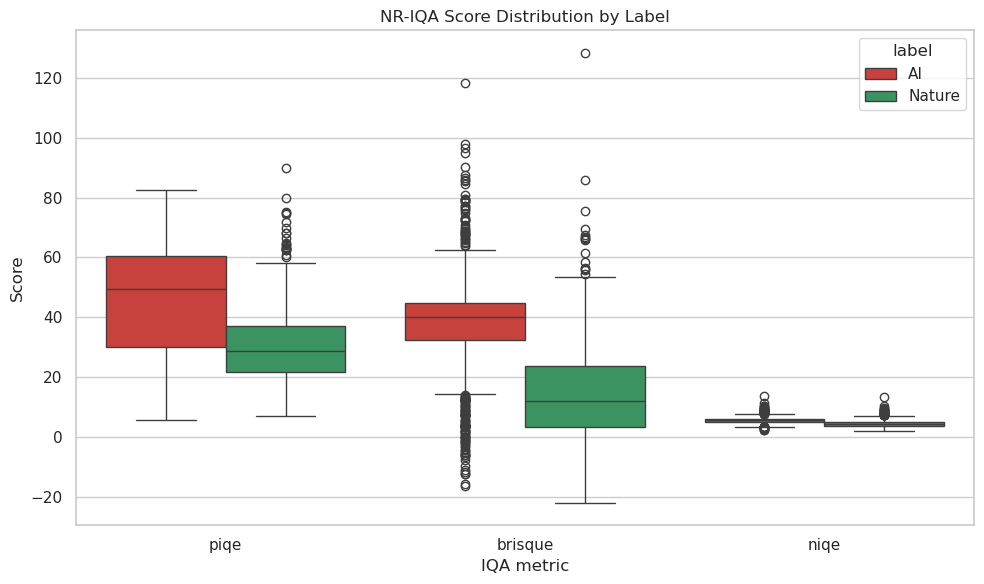

In [13]:
# Boxplot IQA per label untuk melihat pergeseran distribusi kualitas.
iqa_long = iqa_vis.melt(
    id_vars=["image_id", "generator", "class_name", "label", "y_ai"],
    value_vars=iqa_cols,
    var_name="metric",
    value_name="score",
)

plt.figure(figsize=(10, 6))
sns.boxplot(data=iqa_long, x="metric", y="score", hue="label", palette=PALETTE)
plt.title("NR-IQA Score Distribution by Label")
plt.xlabel("IQA metric")
plt.ylabel("Score")
savefig("16_iqa_boxplot_by_label.png")
plt.show()

## Grafik Performa dari CSV Hasil Eksperimen

Bagian ini membaca file `results_classification_*.csv` yang sudah tersimpan. Tidak ada training ulang. Grafik ini berguna untuk laporan kuantitatif agar hasil tidak hanya berupa tabel.

         feature_set    model  accuracy        f1
0           FFT only  XGBoost  0.984375  0.984227
1           FFT only      MLP  0.968750  0.968354
2          CLIP only      MLP  0.965625  0.965517
3          CLIP only  XGBoost  0.946875  0.948012
4           IQA only      MLP  0.831250  0.832298
5           IQA only  XGBoost  0.815625  0.817337
6         FFT + CLIP  XGBoost  0.990625  0.990596
7         FFT + CLIP      MLP  0.971875  0.971963
8          IQA + FFT  XGBoost  0.984375  0.984326
9          IQA + FFT      MLP  0.925000  0.924051
10        IQA + CLIP      MLP  0.968750  0.968750
11        IQA + CLIP  XGBoost  0.946875  0.947692
12  IQA + FFT + CLIP  XGBoost  0.987500  0.987500
13  IQA + FFT + CLIP      MLP  0.978125  0.978056


,feature_set,model,accuracy,f1
0,FFT only,XGBoost,0.984375,0.984227
1,FFT only,MLP,0.968750,0.968354
2,CLIP only,MLP,0.965625,0.965517
3,CLIP only,XGBoost,0.946875,0.948012
4,IQA only,MLP,0.831250,0.832298
5,IQA only,XGBoost,0.815625,0.817337
6,FFT + CLIP,XGBoost,0.990625,0.990596
7,FFT + CLIP,MLP,0.971875,0.971963
8,IQA + FFT,XGBoost,0.984375,0.984326
9,IQA + FFT,MLP,0.925000,0.924051


Saved: /home/nanda/folder belajar/TA-2026/nr_iqa_genimage_scaffold/artifacts/figures/16_model_performance_by_feature_set.png


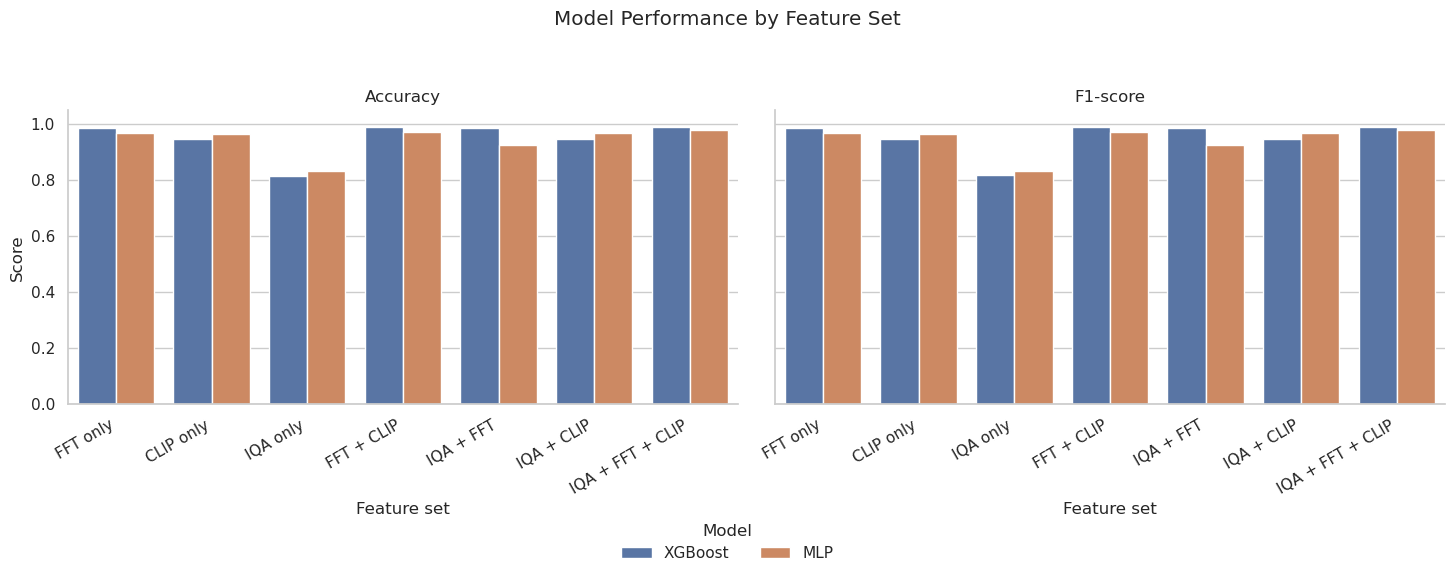

In [14]:
result_rows = []
for feature_set, path in RESULT_FILES.items():
    if not path.exists():
        print("Missing:", path)
        continue
    df = pd.read_csv(path)
    df["feature_set"] = feature_set
    result_rows.append(df)

results = pd.concat(result_rows, ignore_index=True)
metric_cols = [c for c in ["accuracy", "f1"] if c in results.columns]
print(results[["feature_set", "model", *metric_cols]])

display(results[["feature_set", "model", *metric_cols]])

results_long = results.melt(
    id_vars=["feature_set", "model"],
    value_vars=metric_cols,
    var_name="metric",
    value_name="score",
)

metric_titles = {"accuracy": "Accuracy", "f1": "F1-score"}
g = sns.catplot(
    data=results_long,
    kind="bar",
    x="feature_set",
    y="score",
    hue="model",
    col="metric",
    col_order=metric_cols,
    errorbar=None,
    height=5,
    aspect=1.35,
    sharey=True,
)
g.set_titles("{col_name}")
for ax in g.axes.flat:
    metric = ax.get_title()
    ax.set_title(metric_titles.get(metric, metric))
    ax.set_xlabel("Feature set")
    ax.set_ylabel("Score")
    ax.set_ylim(0, 1.05)
    ax.tick_params(axis="x", rotation=30)
    for label in ax.get_xticklabels():
        label.set_horizontalalignment("right")

sns.move_legend(
    g,
    "lower center",
    bbox_to_anchor=(0.5, -0.08),
    ncol=2,
    title="Model",
    frameon=False,
)
g.fig.suptitle("Model Performance by Feature Set", y=1.05)
g.fig.subplots_adjust(bottom=0.25)
savefig("16_model_performance_by_feature_set.png")
plt.show()
